## PRE-EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
RANDOM_SEED = 0

In [3]:
!wget https://proai-datasets.s3.eu-west-3.amazonaws.com/credit_scoring.csv
df = pd.read_csv("credit_scoring.csv")

--2025-10-21 18:31:10--  https://proai-datasets.s3.eu-west-3.amazonaws.com/credit_scoring.csv
Resolving proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)... 3.5.206.231, 3.5.205.23
Connecting to proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)|3.5.206.231|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46985859 (45M) [text/csv]
Saving to: ‘credit_scoring.csv.1’

credit_scoring.csv. 100%[===================>]  44.81M  15.7MB/s    in 2.9s    

2025-10-21 18:31:13 (15.7 MB/s) - ‘credit_scoring.csv.1’ saved [46985859/46985859]



In [4]:
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,424380.57,Working,Higher education,Civil marriage,Rented apartment,-11778.0,-4438.0,1.0,1.0,0.0,0.0,NaN,2.0,0
1,5008805,M,Y,Y,0,421593.52,Working,Higher education,Civil marriage,Rented apartment,-11777.0,-4459.0,1.0,1.0,0.0,0.0,NaN,2.0,0
2,5008806,M,Y,Y,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,-21471.0,-1144.0,1.0,0.0,0.0,0.0,Security staff,2.0,0
3,5008808,F,N,Y,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-18489.0,-3122.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
4,5008809,F,N,Y,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19093.0,-3070.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1


In [5]:
df.shape

(338427, 19)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338427 entries, 0 to 338426
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   338427 non-null  int64  
 1   CODE_GENDER          338427 non-null  object 
 2   FLAG_OWN_CAR         338427 non-null  object 
 3   FLAG_OWN_REALTY      338427 non-null  object 
 4   CNT_CHILDREN         338427 non-null  int64  
 5   AMT_INCOME_TOTAL     338427 non-null  float64
 6   NAME_INCOME_TYPE     338427 non-null  object 
 7   NAME_EDUCATION_TYPE  338427 non-null  object 
 8   NAME_FAMILY_STATUS   338426 non-null  object 
 9   NAME_HOUSING_TYPE    338426 non-null  object 
 10  DAYS_BIRTH           338426 non-null  float64
 11  DAYS_EMPLOYED        338426 non-null  float64
 12  FLAG_MOBIL           338426 non-null  float64
 13  FLAG_WORK_PHONE      338426 non-null  float64
 14  FLAG_PHONE           338426 non-null  float64
 15  FLAG_EMAIL       

Il dataset è composto da un totale di **338.427 osserviazioni** e **19 variabili**, di cui **8 numeriche** e **8 categoriche**.

Per prima cosa notiamo la colonna **ID**, poco significativa per il nostro progetto e andiamo quindi a rimuoverla.

In [7]:
# Remove ID column
df = df.drop(["ID"], axis=1)

In [8]:
# Check for missing and duplicate values
print("Missing values ​​per column: \n", df.isnull().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values ​​per column: 
 CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          1
NAME_HOUSING_TYPE           1
DAYS_BIRTH                  1
DAYS_EMPLOYED               1
FLAG_MOBIL                  1
FLAG_WORK_PHONE             1
FLAG_PHONE                  1
FLAG_EMAIL                  1
OCCUPATION_TYPE        103342
CNT_FAM_MEMBERS             1
TARGET                      0
dtype: int64

Number of duplicate rows: 0


La variabile **OCCUPATION_TYPE** presenta molti valori mancanti (103.342) mentre altre variabili presentano un solo valore mancante: **NAME_FAMILY_STATUS**, **NAME_HOUSING_TYPE**, **DAYS_BIRTH**, **DAYS_EMPLOYED**, **FLAG_MOBIL**, **FLAG_WORK_PHONE**, **FLAG_PHONE**, **FLAG_EMAIL**, **CNT_FAM_MEMBERS**

## FUNCTIONS

In [9]:
# Function for preprocessing
def preprocess_df(df: pd.DataFrame) -> pd.DataFrame:

    df = df.copy()

    # Remove the feature that we saw was useless
    df = df.drop(["FLAG_MOBIL"], axis=1, errors="ignore")

    # Mapping binary features
    binary_maps = {
        "FLAG_OWN_CAR": {"N": 0, "Y": 1},
        "FLAG_OWN_REALTY": {"N": 0, "Y": 1},
        "CODE_GENDER": {"M": 0, "F": 1},
    }
    for col, mapping in binary_maps.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    # Pensioners flag and derivation of age/years of work
    if {"DAYS_EMPLOYED", "NAME_INCOME_TYPE", "DAYS_BIRTH"}.issubset(df.columns):
        sentinel_threshold = 70 * 365

        df["IS_PENSIONER"] = (
            (df["DAYS_EMPLOYED"] > sentinel_threshold) | (df["NAME_INCOME_TYPE"] == "Pensioner")
        ).astype(int)

        df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.25

        df["EMPLOYMENT_YEARS"] = np.where(
            df["DAYS_EMPLOYED"] < 0, -df["DAYS_EMPLOYED"] / 365.25, 0.0
        )

        df.drop(columns=["DAYS_BIRTH", "DAYS_EMPLOYED"], inplace=True, errors="ignore")

    # Replace NaN ​​with "Missing" for categorical columns
    cat_cols = ["NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "OCCUPATION_TYPE"]
    for col in cat_cols:
        if col in df.columns:
            if col == "OCCUPATION_TYPE":
                df["OCCUPATION_TYPE_MISSING"] = df[col].isna().astype(int)
                df.loc[
                    (df[col].isna()) & (df["NAME_INCOME_TYPE"] == "Pensioner"),
                    col
                ] = "Pensioner"
                df[col] = df[col].fillna("Missing")
            else:
                df[col] = df[col].fillna("Missing")

    return df

In [10]:
# Function for evaluate model
def evaluate_model(y_true, y_pred, y_proba, set_name="Set"):
    print(f"\n=== {set_name} ===")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_true, y_proba):.3f}")

## EDA

In [11]:
df_eda = df.copy()

####*TARGET Analysis:*

In [12]:
# Target distribution
target_counts = df_eda["TARGET"].value_counts()
print("Target distribution:")
print(f"TARGET 0 (Not Reliable): {target_counts[0]} ({target_counts[0]/target_counts.sum()*100:.2f} %)")
print(f"TARGET 1 (Reliable): {target_counts[1]} ({target_counts[1]/target_counts.sum()*100:.2f} %)")

Target distribution:
TARGET 0 (Not Reliable): 308705 (91.22 %)
TARGET 1 (Reliable): 29722 (8.78 %)



Il dataset presenta un forte sbilanciamento della variabile **TARGET** e di conseguenza il modello potrebbe avere difficoltà a identificare correttamente la classe minoritaria *(Target 1: Reliable)*.

####*Analysis of categorical variables:*

In [13]:
# Formatting categorical features
cat_features = [
    "FLAG_MOBIL", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL"
]
for col in cat_features:
    df_eda[col] = df_eda[col].astype("object")

In [14]:
# Categorical Statistics
print("Categorical features statistics:")
print(df_eda.select_dtypes(include="object").describe().T)

Categorical features statistics:
                        count unique                            top      freq
CODE_GENDER            338427      2                              F    227916
FLAG_OWN_CAR           338427      2                              N    213196
FLAG_OWN_REALTY        338427      2                              Y    231307
NAME_INCOME_TYPE       338427      5                        Working    174366
NAME_EDUCATION_TYPE    338427      6  Secondary / secondary special    232568
NAME_FAMILY_STATUS     338426      5                        Married    231494
NAME_HOUSING_TYPE      338426      6              House / apartment    304410
FLAG_MOBIL           338426.0    1.0                            1.0  338426.0
FLAG_WORK_PHONE      338426.0    2.0                            0.0  266890.0
FLAG_PHONE           338426.0    2.0                            0.0  239165.0
FLAG_EMAIL           338426.0    2.0                            0.0  302830.0
OCCUPATION_TYPE        235085  

In [15]:
# Numerical statistics
print("Numerical features statistics:")
print(df_eda.select_dtypes(exclude="object").describe().T)

Numerical features statistics:
                     count           mean            std       min        25%  \
CNT_CHILDREN      338427.0       0.428934       0.727990      0.00       0.00   
AMT_INCOME_TOTAL  338427.0  187668.547635  110786.279376  25548.98  121229.95   
DAYS_BIRTH        338426.0  -15998.212897    4193.088539 -26636.00  -19467.00   
DAYS_EMPLOYED     338426.0   60234.533869  138522.923248 -17973.00   -3116.00   
CNT_FAM_MEMBERS   338426.0       2.197228       0.899570      1.00       2.00   
TARGET            338427.0       0.087824       0.283039      0.00       0.00   

                        50%         75%         max  
CNT_CHILDREN           0.00       1.000       19.00  
AMT_INCOME_TOTAL  162855.26  225208.155  7071015.83  
DAYS_BIRTH        -15623.00  -12516.250    -7566.00  
DAYS_EMPLOYED      -1483.00    -378.000   396498.00  
CNT_FAM_MEMBERS        2.00       3.000       20.00  
TARGET                 0.00       0.000        1.00  


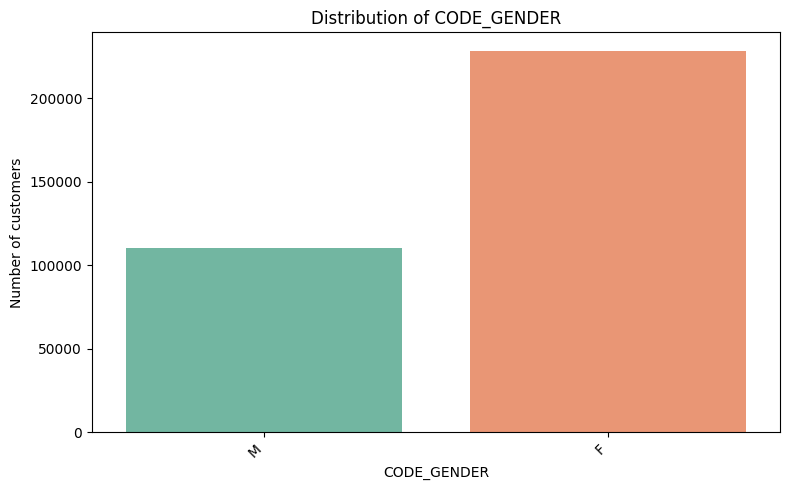

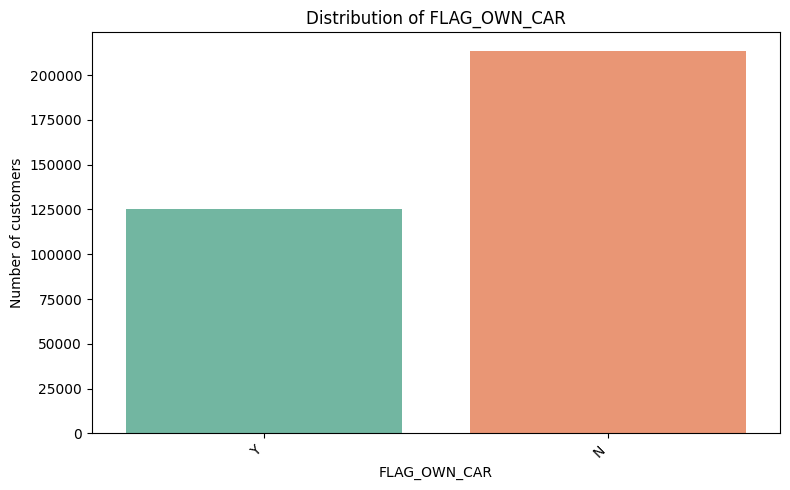

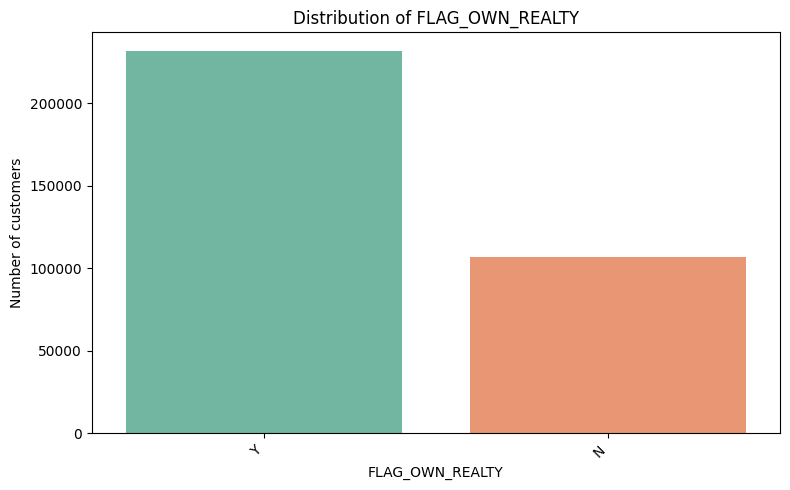

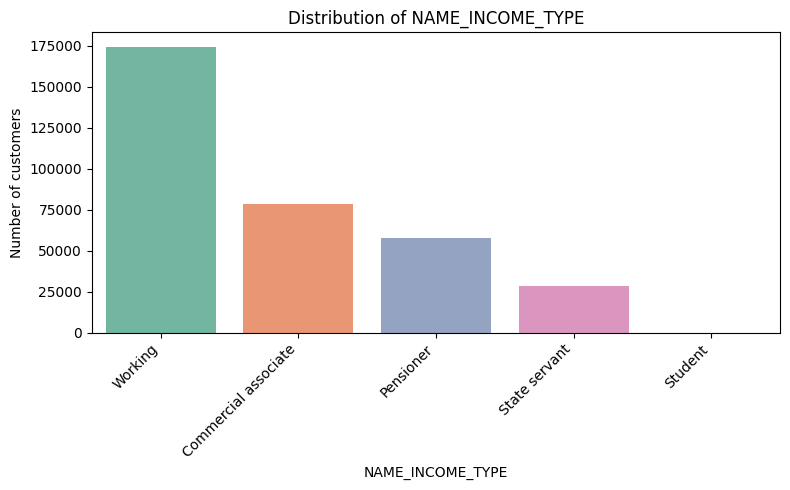

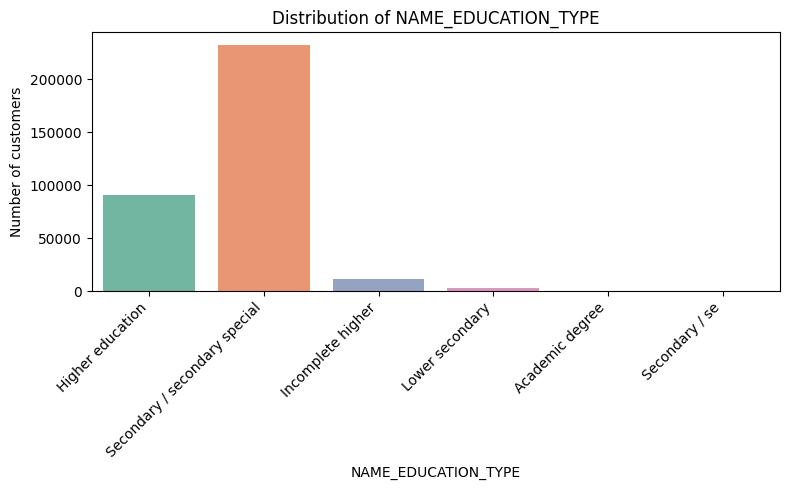

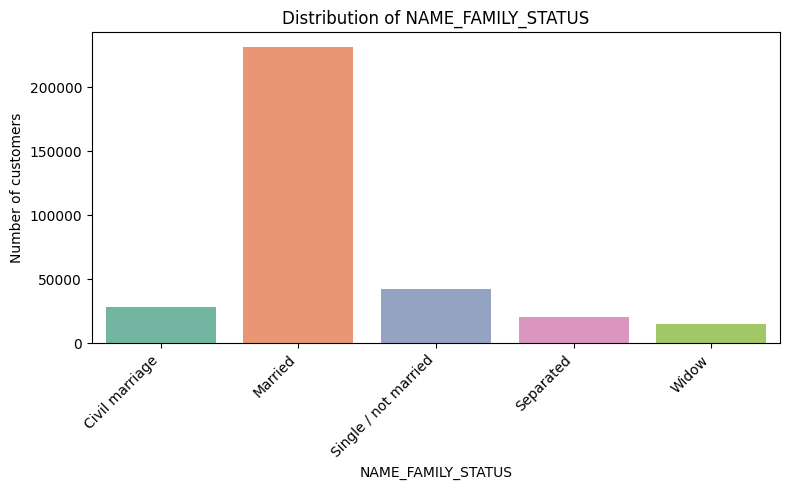

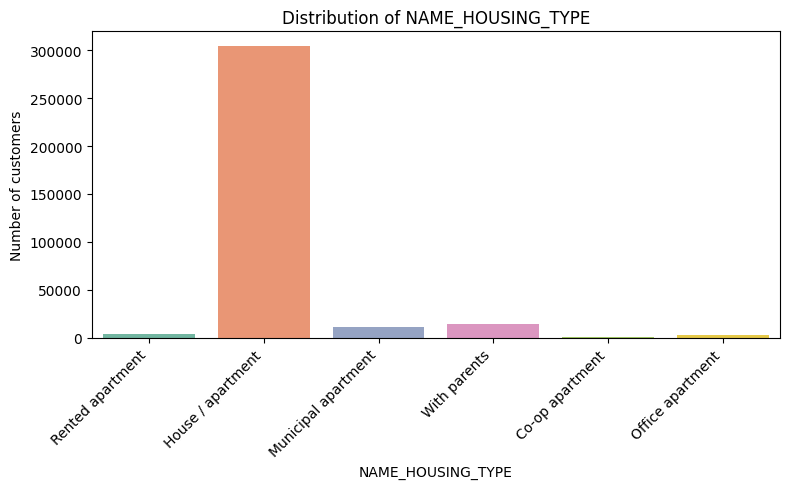

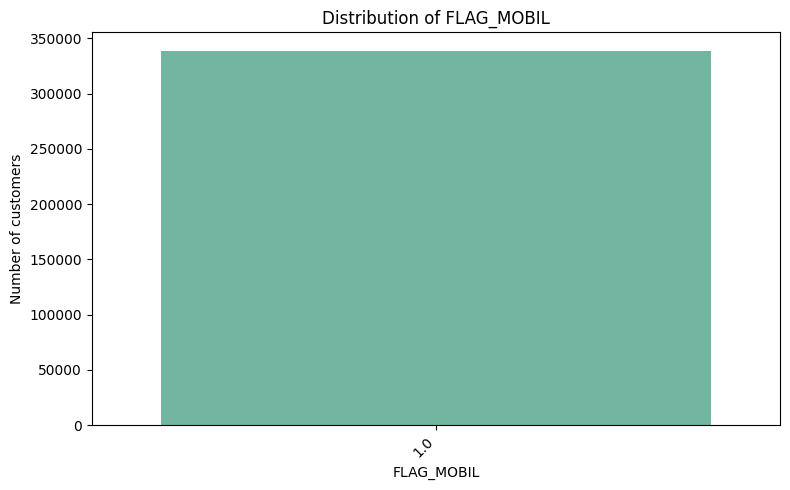

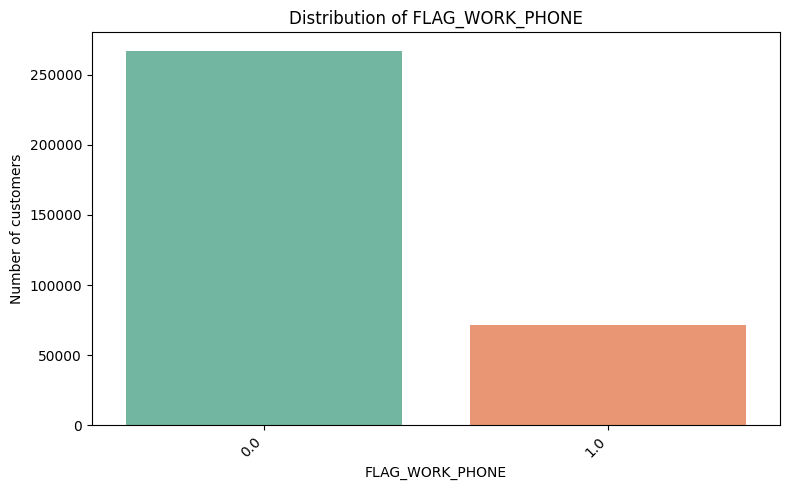

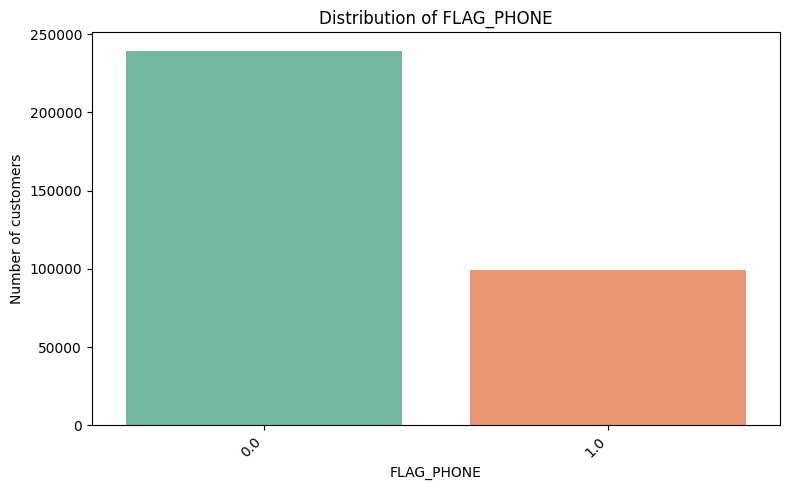

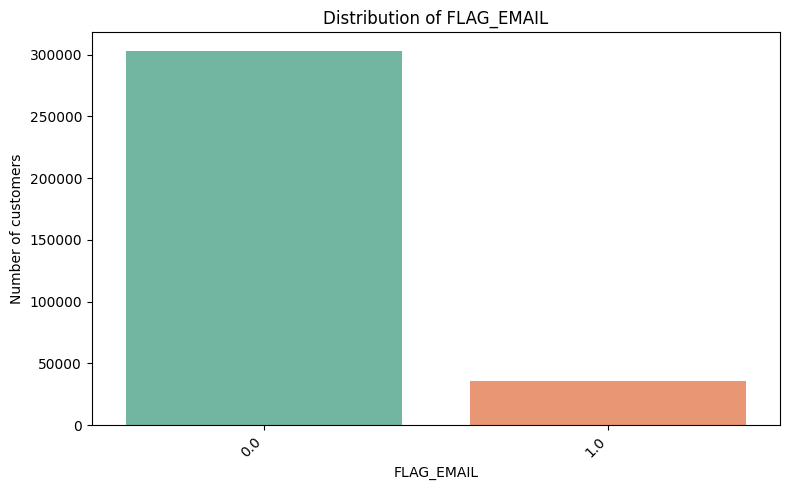

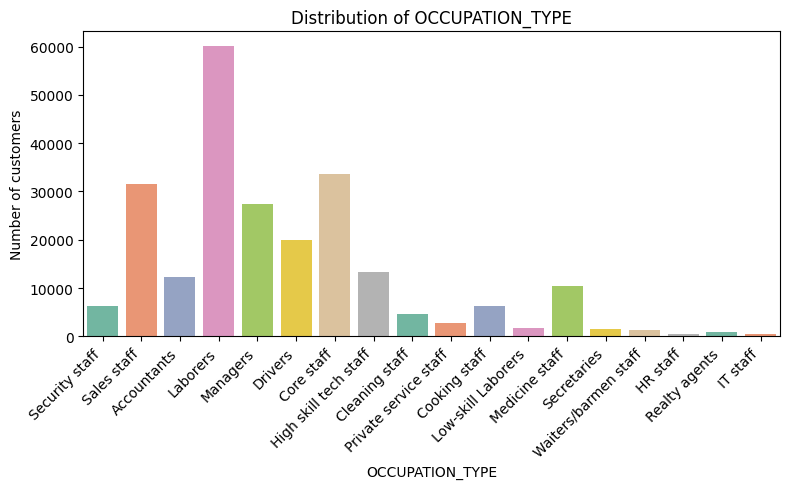

In [16]:
# Distribution of categorical features
cat_cols = df_eda.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols:
    plt.figure(figsize=(8,5))
    ax = sns.countplot(x=col, hue=col, data=df_eda, palette="Set2", legend=False)
    plt.title(f"Distribution of {col}")
    plt.ylabel("Number of customers")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

**CODE_GENDER**: la distribuzione presenta una netta prevalenza di clienti femmine (67%) rispetto a clienti maschi (33%).

**FLAG_OWN_CAR**: la maggior parte dei clienti non possiede un auto (63%), mentre una quota minore (37%) invece la possiede.

**FLAG_OWN_REALTY**: la maggior parte dei clienti possiede un immobile ad uso abitativo (68%), mentre una quota minore (32%) non ne è proprietaria.

**NAME_INCOME_TYPE**: la categoria *Working* (52%) registra il numero più elevato di osservazioni, seguita da *Commercial associate* (23%), *Pensioner* (17%) e *State servant* (8%), mentre la categoria *Student* (0,01%) è quasi nulla.

**NAME_EDUCATION_TYPE**: la categoria *Secondary/secondary special* (69%) domina nettamente, seguita a distanza da *Higher education* (27%), mentre *Incomplete higher* (3%), *Lower secondary* (1%) e *Academic degree* (0,07%) presentano conteggi bassi o quasi nulli nel campione osservato.
Inoltre è presente una singola osservazione "Secondary / se" che possiamo considerare chiaramente un errore di trascrizione.

**NAME_FAMILY_STATUS**: la categoria *Married* (68%) è nettamente predominante, mentre *Single/not married* (13%), *Civil marriage* (8%), *Separated* (6%) e *Widow* (4%) presentano conteggi significativamente più bassi nel campione oseervato.

**NAME_HOUSING_TYPE**: la categoria *House/apartment* (90%) domina nettamente il campione, mentre *With parents* (4%) e *Municipal apartment* (3%) presentano conteggi molto inferiori, e *Rented apartment*, *Co‑op apartment* e *Office apartment* risultano marginali.

**OCCUPATION_TYPE**: le categorie più numerose sono *Laborers* (26%), *Core staff* (14%) e *Sales staff* (13%), seguite da *Managers* (12%) e *Drivers* (9%). Le categorie di media dimensione includono *High skill tech staff* (6%), *Accountants* (5%) e *Medicine staff* (4%). Tutte le altre occupazioni rappresentano ciascuna meno del 3% del campione, con le più piccole come *HR staff* (0,24%) e *IT staff* (0,19%) che risultano marginali.

Le variabili **FLAG_MOBIL**, **FLAG_WORK_PHONE**, **FLAG_PHONE**, **FLAG_EMAIL** sono binarie, con 0 generalmente interpretato come "No" e 1 come "Yes"; tuttavia, la documentazione del dataset non conferma esplicitamente questa codifica. Notiamo inoltre che **FLAG_MOBIL** presenta un solo valore, rendendola quindi trascurabile.

In [17]:
# Fix error in NAME_EDUCATION_TYPE
df_eda["NAME_EDUCATION_TYPE"] = df_eda["NAME_EDUCATION_TYPE"].replace("Secondary / se", "Secondary / secondary special")
df["NAME_EDUCATION_TYPE"] = df["NAME_EDUCATION_TYPE"].replace("Secondary / se", "Secondary / secondary special")

In [18]:
# Relationship between OCCUPATION_TYPE and NAME_INCOME_TYPE
n_missing = df_eda["OCCUPATION_TYPE"].isna().sum()
print(f"Total NaN in OCCUPATION_TYPE: {n_missing:,}")

# NaN count by income type
nan_counts = df_eda.loc[df_eda["OCCUPATION_TYPE"].isna(), "NAME_INCOME_TYPE"].value_counts()
print("\nDistribution of NAME_INCOME_TYPE for cases with missing OCCUPATION_TYPE:")
display(nan_counts)

# Overall distribution for comparison
print("\nDistribution of NAME_INCOME_TYPE:")
display(df_eda["NAME_INCOME_TYPE"].value_counts())

Total NaN in OCCUPATION_TYPE: 103,342

Distribution of NAME_INCOME_TYPE for cases with missing OCCUPATION_TYPE:


,count
NAME_INCOME_TYPE,
Pensioner,57841
Working,27784
Commercial associate,12927
State servant,4785
Student,5



Distribution of NAME_INCOME_TYPE:


,count
NAME_INCOME_TYPE,
Working,174366
Commercial associate,78090
Pensioner,57841
State servant,28113
Student,17


Dalla relazione tra **OCCUPATION_TYPE** e **NAME_INCOME_TYPE** emerge che la categoria **“Pensioner”** conta esattamente 57.841 casi, tutti privi di un valore in OCCUPATION_TYPE.
Questo indica che i pensionati non presentano un’occupazione attiva e che i loro NaN sono coerenti con la natura del dato.
Si procede quindi ad assegnare il valore "Pensioner" a OCCUPATION_TYPE, così da ridurre significativamente i valori mancanti e migliorare la qualità del dataset.

In [19]:
# Replace NaN in OCCUPATION_TYPE with "Pensioner" for retirees
df_eda.loc[
    (df_eda["OCCUPATION_TYPE"].isna()) & (df_eda["NAME_INCOME_TYPE"] == "Pensioner"),
    "OCCUPATION_TYPE"
] = "Pensioner"

# Check
remaining_nan = df_eda.loc[
    df_eda["NAME_INCOME_TYPE"] == "Pensioner", "OCCUPATION_TYPE"
].isna().sum()

print(f"NaN remaining in Pensioners: {remaining_nan}")

NaN remaining in Pensioners: 0


####*Analysis of numerical variables:*

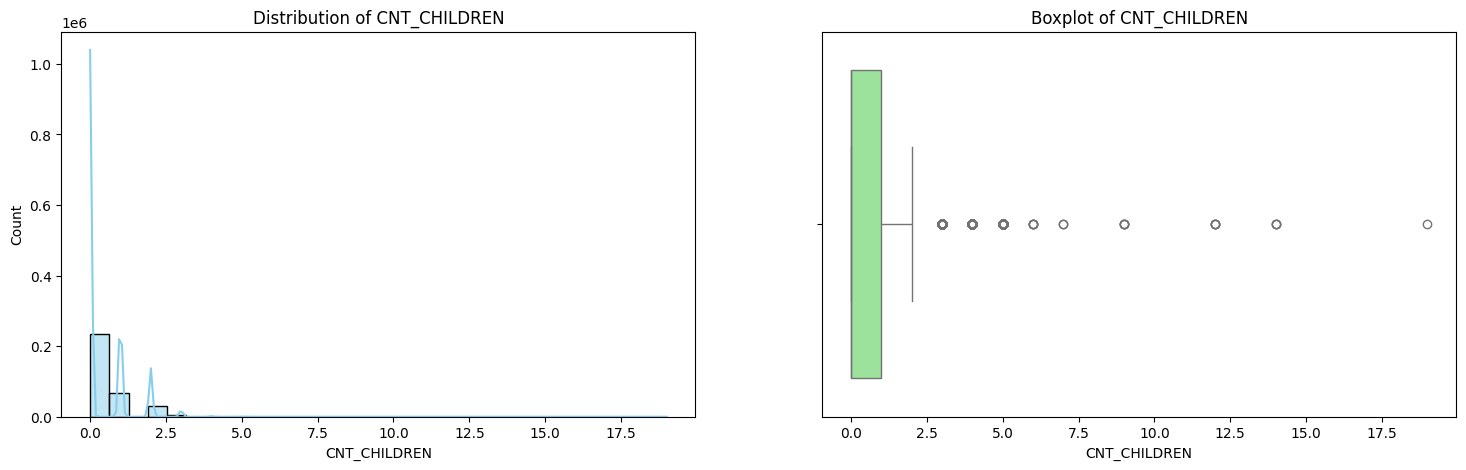

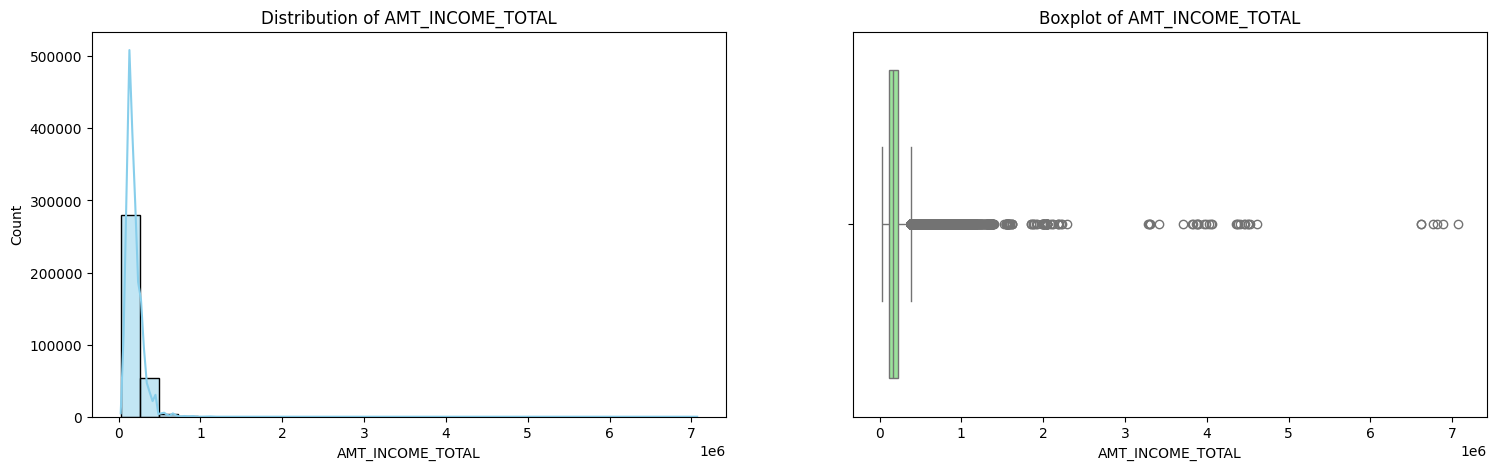

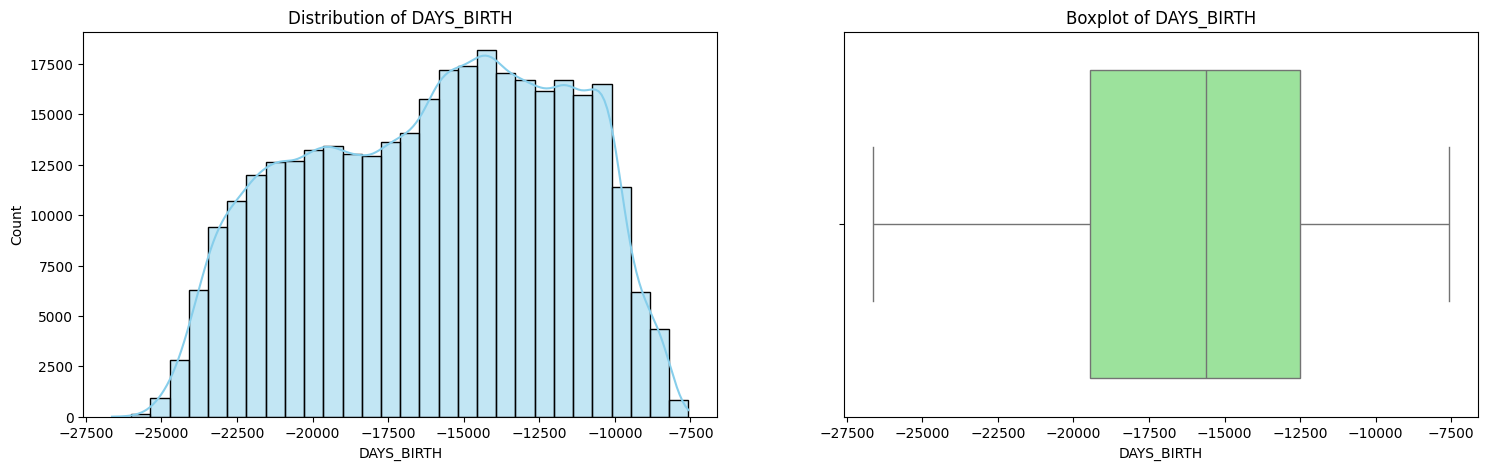

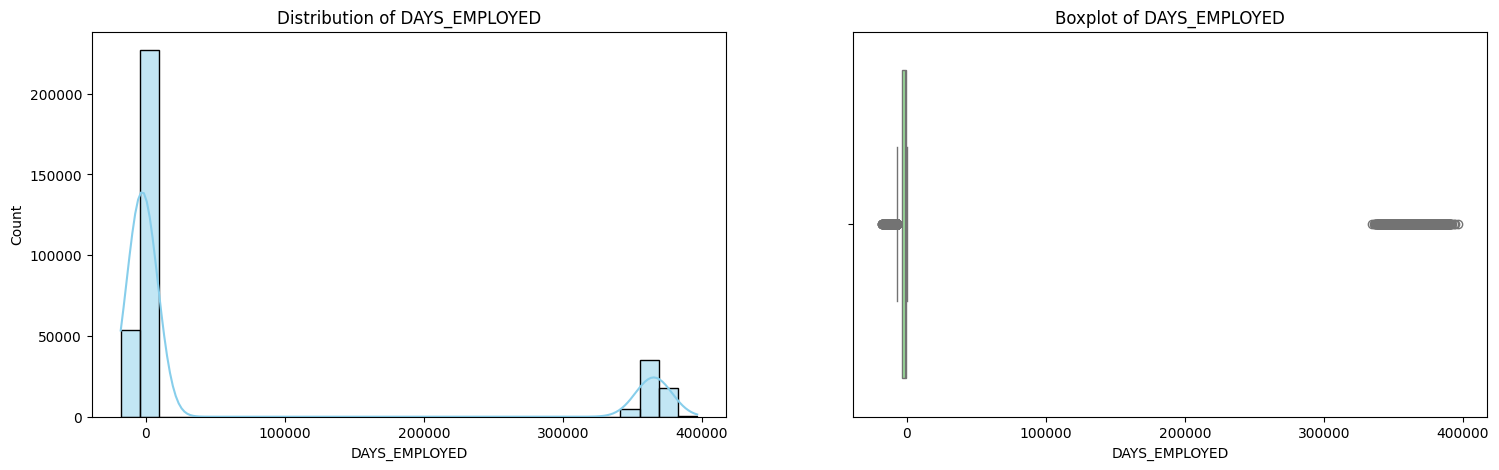

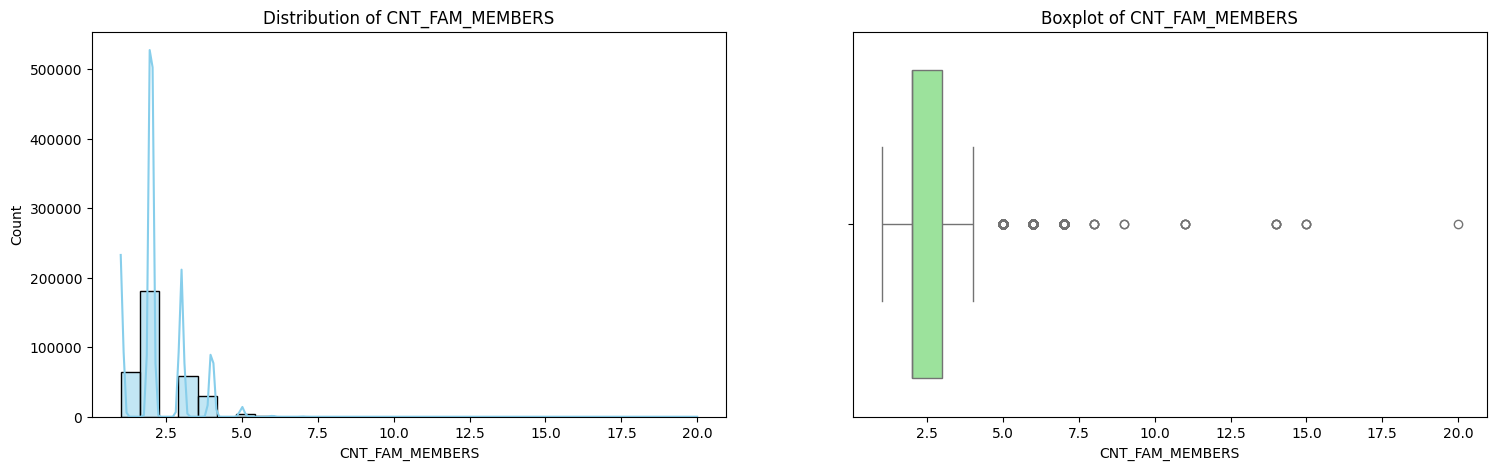

In [20]:
# Distribution of numerical features except for "TARGET"
num_cols = df_eda.select_dtypes(exclude="object").columns.drop("TARGET")

for col in num_cols:
    plt.figure(figsize=(18,5))

    plt.subplot(1,2,1)
    sns.histplot(df_eda[col], bins=30, kde=True, color="skyblue")
    plt.title(f"Distribution of {col}")

    plt.subplot(1,2,2)
    sns.boxplot(x=df_eda[col], color="lightgreen")
    plt.title(f"Boxplot of {col}")

    plt.show()

**CNT_CHILDREN**: si evidenzia una marcata asimmetria a destra: la maggior parte dei clienti ha 0 o 1 figlio, mentre pochi outlier presentano un numero di figli molto elevato, arrivando fino a 19 figli.

**AMT_INCOME_TOTAL**: si evidenzia una marcata asimmetria a destra: la maggior parte dei redditi si concentra tra poche decine e alcune centinaia di migliaia, mentre pochi casi isolati raggiungono valori molto elevati (circa 7 milioni).

**DAYS_BIRTH**: la distribuzione è espressa in giorni negativi, con valori compresi tra circa −27.000 e −7.500 giorni (pari a 74–21 anni). La densità è maggiore tra −16.000 e −14.000 giorni (circa 44–38 anni), indicando una concentrazione della popolazione nella mezza età e l’assenza di outlier estremi.

**DAYS_EMPLOYED**: la maggior parte dei valori si concentra vicino allo zero, con una coda destra che riflette un’anzianità lavorativa compresa tra pochi anni e alcune decine d’anni. Notiamo però un picco anomalo tra 350.000 e 400.000 giorni, che risulta invece irrealistico e potrebbe rappresentare un valore sentinella.

**CNT_FAM_MEMBERS**: si evidenzia una distribuzione discreta e fortemente concentrata tra 1 e 4 membri familiari, con picchi marcati a 2/3 membri e una coda destra con rari outlier fino a circa 20 membri.

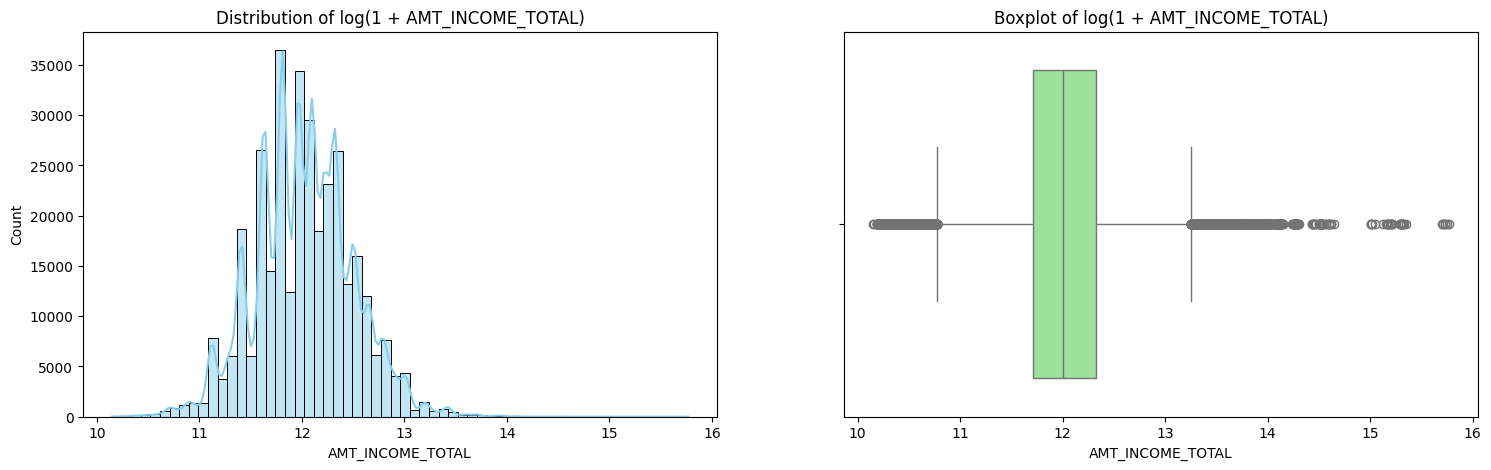

In [21]:
# Analysis of AMT_INCOME_TOTAL
if "AMT_INCOME_TOTAL" in df_eda.columns:
    plt.figure(figsize=(18,5))

    plt.subplot(1,2,1)
    sns.histplot(np.log1p(df_eda["AMT_INCOME_TOTAL"]), bins=60, kde=True, color="skyblue")
    plt.title("Distribution of log(1 + AMT_INCOME_TOTAL)")

    plt.subplot(1,2,2)
    sns.boxplot(x=np.log1p(df_eda["AMT_INCOME_TOTAL"]), color="lightgreen")
    plt.title("Boxplot of log(1 + AMT_INCOME_TOTAL)")

    plt.show()

Per migliorare la leggibilità e agevolare la modellizzazione, implemento sulla variabile **AMT_INCOME_TOTAL** la trasformazione log(1 + x), che rende la distribuzione più simmetrica e vicina a una forma gaussiana, facilitando l’interpretazione e ottimizzando le prestazioni dei modelli sensibili alla scala o alla normalità dei dati.

In [22]:
# Sentinel value for Pensioners
retirement_age_days = 70 * 365

n_sentinel = df_eda[df_eda["DAYS_EMPLOYED"] > retirement_age_days]
print(f"People with DAYS_EMPLOYED > 70 years (≈ pensioners): {len(n_sentinel):,}")

if "NAME_INCOME_TYPE" in df_eda.columns and not n_sentinel.empty:
    retirement_income_dist = n_sentinel["NAME_INCOME_TYPE"].value_counts()
    print("\nNAME_INCOME_TYPE categories for these cases")
    display(retirement_income_dist)

People with DAYS_EMPLOYED > 70 years (≈ pensioners): 57,841

NAME_INCOME_TYPE categories for these cases


,count
NAME_INCOME_TYPE,
Pensioner,57841


L’analisi congiunta tra **DAYS_EMPLOYED** e **NAME_INCOME_TYPE** ha evidenziato che i valori estremamente elevati (oltre 70 anni) non rappresentano durate reali di impiego, ma costituiscono una codifica artificiale per identificare i clienti pensionati. Ciò viene confermato sia dalla concentrazione dei valori attorno a un picco fisso, sia dalla perfetta corrispondenza con la categoria *“Pensioner”*, a cui appartengono tutti i 57.841 casi rilevati.

In fase di preprocessing, verranno implementati i seguenti passaggi:

*   Creazione di un flag binario **IS_PENSIONER** per identificare i clienti codificati artificialmente come pensionati;
*   Neutralizzazione dei valori anomali presenti in **DAYS_EMPLOYED** impostandoli a NaN;
*   Creazione di nuove feature interpretabili: **EMPLOYMENT_YEARS** e **UNEMPLOYED_YEARS**.

Queste operazioni permetteranno di distinguere immediatamente clienti occupati, disoccupati e pensionati.

IS_PENSIONER
0    280586
1     57841
Name: count, dtype: int64

NaN in DAYS_EMPLOYED after neutralization: 57842



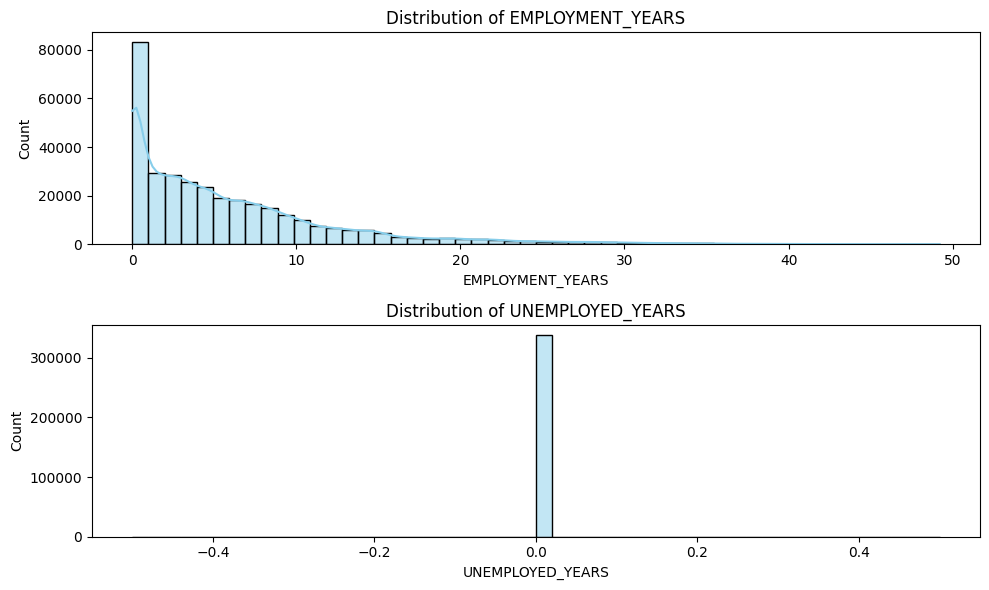

In [23]:
# Flag "IS_PENSIONER"
df_eda["IS_PENSIONER"] = (
    (df_eda["DAYS_EMPLOYED"] > 70 * 365) |
    (df_eda["NAME_INCOME_TYPE"] == "Pensioner")
).astype(int)

# Replace sentinel values ​​with NaN
sentinel_threshold = 70 * 365
df_eda.loc[df_eda["DAYS_EMPLOYED"] > sentinel_threshold, "DAYS_EMPLOYED"] = np.nan

# Calculating years of Employment and Unemployment
days = df_eda["DAYS_EMPLOYED"]
df_eda["EMPLOYMENT_YEARS"] = np.where(days < 0, -days / 365.25, 0)
df_eda["UNEMPLOYED_YEARS"] = np.where((days > 0) & (days <= sentinel_threshold), days / 365.25, 0)

# Check
print(df_eda["IS_PENSIONER"].value_counts())
n_nan = df_eda["DAYS_EMPLOYED"].isna().sum()
print(f"\nNaN in DAYS_EMPLOYED after neutralization: {n_nan}\n")

# Visualization
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
sns.histplot(df_eda["EMPLOYMENT_YEARS"].dropna(), bins=50, kde=True, color="skyblue")
plt.title("Distribution of EMPLOYMENT_YEARS")

plt.subplot(2, 1, 2)
sns.histplot(df_eda["UNEMPLOYED_YEARS"].dropna(), bins=50, kde=True, color="skyblue")
plt.title("Distribution of UNEMPLOYED_YEARS")

plt.tight_layout()
plt.show()

In [24]:
print(df_eda["UNEMPLOYED_YEARS"].describe())

count    338427.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: UNEMPLOYED_YEARS, dtype: float64


La distribuzione evidenzia una concentrazione degli anni di occupazione su valori ridotti, segno di un’anzianità lavorativa generalmente bassa. Gli anni di disoccupazione risultano nulli, in quanto i valori sentinella associati ai pensionati sono stati correttamente neutralizzati, riflettendo una popolazione composta prevalentemente da lavoratori o pensionati.

In [25]:
# Removing UNEMPLOYED_YEARS
df_eda.drop(columns=["UNEMPLOYED_YEARS"], inplace=True)

####*Analysis on TARGET:*

In [26]:
# Means of numeric variables for TARGET
print("Means of numeric variables for TARGET:")

mean_by_target = df_eda.groupby("TARGET")[num_cols].mean().round(3).T
mean_by_target = mean_by_target.sort_values(by=[0, 1], ascending=False)
display(mean_by_target)

# Average TARGET rate by category
for col in cat_cols:
    counts = df_eda[col].value_counts().rename("count")
    target_rate = df_eda.groupby(col)["TARGET"].mean().round(3).rename("target_rate")
    summary = (
        pd.concat([target_rate, counts], axis=1)
        .sort_values("count", ascending=False)
    )
    print(f"\n{col} – TARGET Rate:")
    display(summary)


Means of numeric variables for TARGET:


TARGET,0,1
AMT_INCOME_TOTAL,179957.412,267759.590
CNT_FAM_MEMBERS,2.219,1.971
CNT_CHILDREN,0.450,0.214
DAYS_EMPLOYED,-2398.245,-4644.157
DAYS_BIRTH,-15758.786,-18484.992



CODE_GENDER – TARGET Rate:


,target_rate,count
CODE_GENDER,,
F,0.085,227916
M,0.094,110511



FLAG_OWN_CAR – TARGET Rate:


...

,target_rate,count
FLAG_PHONE,,
0.0,0.085,239165
1.0,0.095,99261



FLAG_EMAIL – TARGET Rate:


,target_rate,count
FLAG_EMAIL,,
0.0,0.086,302830
1.0,0.105,35596



OCCUPATION_TYPE – TARGET Rate:


,target_rate,count
OCCUPATION_TYPE,,
Laborers,0.097,60146
Pensioner,0.000,57841
Core staff,0.100,33527
Sales staff,0.065,31652
Managers,0.179,27384
Drivers,0.108,20020
High skill tech staff,0.119,13399
Accountants,0.132,12281
Medicine staff,0.137,10438


Analizzando la tabella generata per le variabili numeriche possiamo notare differenze significative tra clienti affidabili e non affidabili.

In particolare, i clienti affidabili presentano in media:

*   redditi più alti (**AMT_INCOME_TOTAL**);
*   un lavoro stabile (**DAYS_EMPLOYED**);
*   pochi figli e famiglie più piccole (**CNT_CHILDREN** e **CNT_FAM_MEMBERS**);
*   più anzianeità (**DAYS_BIRTH**).

Analizzando invece le variabili categoriche invece possiamo notare che:

*   gli uomini hanno una leggera maggiore probabilità di risultare affidabili;
*   possedere beni (auto e/o casa) è associato ad una maggiore affidabilità creditizia;
*   **Student** (17.6%) e **State servant** (13.4%) risultano essere più affidabili mentre i **Pensioner** risultano tutti non affidabili;
*   più istruzione è associato a più affidabilità;
*   chi vive da solo o ha un’abitazione indipendente tende ad essere più affidabile;
*   ruoli professionali qualificati (**Managers** (17.9%), **HR staff **(15.3%), **Realty agents** (15.3%)) tendono ad avere una maggiore affidabilità creditizia, rispetto a lavori manuali o precari come **Waiters/barmen staff** (2.7%) o **Low-skill Laborers** (5.4%)

In sintesi, il cliente considerato più affidabile è generalmente una persona di età matura, con un alto livello di istruzione, un reddito elevato e un’occupazione stabile.

In [27]:
df_analysis = preprocess_df(df)

# Class breakdown
df_reliable = df_analysis[df_analysis['TARGET'] == 1]
df_not_reliable = df_analysis[df_analysis['TARGET'] == 0]

# Statistics
n_reliable = len(df_reliable)
n_not_reliable = len(df_not_reliable)

print(f"Reliable customers (TARGET=1): {n_reliable:,}")
print(f"Not reliable customers (TARGET=0): {n_not_reliable:,}")
print(f"Ratio: {n_not_reliable / n_reliable:.1f} : 1")

# Selecting numeric variables (excluding TARGET)
numeric_features = []
for col in df_analysis.select_dtypes(include='number'):
    if col != 'TARGET':
        numeric_features.append(col)

# Comparison of averages
mean_reliable = df_reliable[numeric_features].mean()
mean_not_reliable  = df_not_reliable[numeric_features].mean()

comparison = (
    pd.DataFrame({
        'Reliable': mean_reliable,
        'Not_Reliable': mean_not_reliable,
        'Diff %': (mean_not_reliable - mean_reliable) / mean_reliable * 100
    })
    .sort_values('Diff %', key=abs, ascending=False)
    .round(3)
)

print("\nMain differences between classes:")
display(comparison)

Reliable customers (TARGET=1): 29,722
Not reliable customers (TARGET=0): 308,705
Ratio: 10.4 : 1

Main differences between classes:


,Reliable,Not_Reliable,Diff %
IS_PENSIONER,0.000,0.187,inf
CNT_CHILDREN,0.214,0.450,109.883
OCCUPATION_TYPE_MISSING,0.154,0.320,108.138
EMPLOYMENT_YEARS,12.715,5.336,-58.036
AMT_INCOME_TOTAL,267759.590,179957.412,-32.791
FLAG_EMAIL,0.126,0.103,-18.310
AGE_YEARS,50.609,43.145,-14.748
FLAG_OWN_CAR,0.424,0.365,-13.868
CNT_FAM_MEMBERS,1.971,2.219,12.602
FLAG_WORK_PHONE,0.195,0.213,9.512


*Variabili con Differenze Estreme (inf)*

*   **IS_PENSIONER**: solo i clienti non affidabili presentano il flag *“Pensionato”* (0.187 vs 0). Ciò suggerisce che la condizione di pensionamento è associata a un rischio di insolvenza più elevato, probabilmente a causa di redditi fissi e minore capacità di rimborso rispetto ai lavoratori attivi.

*Variabili con Differenze Elevate (>100%)*

*   **CNT_CHILDREN**: iI clienti non affidabili hanno in media più del doppio dei figli rispetto agli affidabili (0.45 vs 0.21, +109.9%). Ciò indica che famiglie numerose con risorse economiche più limitate tendono ad avere maggiori difficoltà finanziarie.
*   **OCCUPATION_TYPE_MISSING**: la quota di clienti con informazioni mancanti sull’occupazione è oltre il doppio tra i non affidabili (0.32 vs 0.15, +108.1%). Questo evidenzia che la mancanza di dati lavorativi o l’assenza di una professione dichiarata rappresentano un forte segnale di rischio creditizio.

*Variabili con Differenze Moderate (30–60%)*

*   **EMPLOYMENT_YEARS**: i clienti affidabili presentano più del doppio degli anni di esperienza lavorativa (12.7 vs 5.3 anni, −58.0%). La stabilità occupazionale emerge come un fattore chiave di affidabilità e capacità di rimborso.
*   **AMT_INCOME_TOTAL**: il reddito medio dei clienti affidabili è nettamente superiore (€267760 vs €179957, −32.8%), confermando che la capacità reddituale è una delle principali determinanti della solidità creditizia.

*Variabili con Differenze Minori (&lt;20%)*

*   **AGE_YEARS**: i clienti affidabili sono più anziani (50.6 vs 43.1 anni, −14.7%).
*   **FLAG_OWN_CAR**: la proprietà di un’auto è leggermente più comune tra gli affidabili (0.42 vs 0.36, −13.9%).
*   **FLAG_EMAIL**: i clienti affidabili forniscono l’e-mail con maggiore frequenza (0.13 vs 0.10, −18.3%).
*   **CNT_FAM_MEMBERS**: i clienti non affidabili vivono in nuclei familiari più grandi (2.22 vs 1.97, +12.6%).
*   **FLAG_WORK_PHONE** / **FLAG_PHONE**: le differenze nei recapiti telefonici sono contenute (&lt;10%).
*   **FLAG_OWN_REALTY**: la proprietà immobiliare è leggermente più diffusa tra gli affidabili (0.73 vs 0.68, −6.8%).
*   **CODE_GENDER**: differenza minima (0.65 vs 0.68, +3.8%): la composizione di genere non mostra impatti rilevanti sull’affidabilità creditizia.

## PRE PROCESSING e SPLIT


Per avviare la fase di modellazione, il dataset viene suddiviso in un **training set (80%)** e un **test set (20%)**, mantenendo in entrambe le porzioni la stessa proporzione di classi (stratificazione del TARGET).
Si definisce quindi una pipeline che gestisce l’intero flusso di preprocessing e addestramento del modello.

Nel preprocessing:

*   tramite la funzione **preprocess_df()**: vengono create le nuove feature AGE_YEARS, EMPLOYMENT_YEARS e IS_PENSIONER; viene rimossa la variabile FLAG_MOBIL (risultata trascurabile dall’EDA); vengono mappate le feature binarie e sostituiti i valori mancanti nelle colonne categoriche con "Missing";
*   le variabili numeriche vengono imputate con la **mediana** e successivamente **standardizzate**;
*   le variabili categoriche vengono imputate con il valore "Missing" e trasformate tramite **One-Hot Encoding**, mantenendo solo le modalità presenti nel training set.

In [28]:
df_clean = preprocess_df(df)

In [29]:
df_clean.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,IS_PENSIONER,AGE_YEARS,EMPLOYMENT_YEARS,OCCUPATION_TYPE_MISSING
0,0,1,1,0,424380.57,Working,Higher education,Civil marriage,Rented apartment,1.0,0.0,0.0,Missing,2.0,0,0,32.246407,12.150582,1
1,0,1,1,0,421593.52,Working,Higher education,Civil marriage,Rented apartment,1.0,0.0,0.0,Missing,2.0,0,0,32.243669,12.208077,1
2,0,1,1,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,0.0,0.0,0.0,Security staff,2.0,0,0,58.784394,3.132101,0
3,1,0,1,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0.0,1.0,1.0,Sales staff,1.0,1,0,50.620123,8.547570,0
4,1,0,1,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0.0,1.0,1.0,Sales staff,1.0,1,0,52.273785,8.405202,0


In [30]:
# Define target variable (y) and feature set (X)
y = df_clean["TARGET"].astype(int)
X = df_clean.drop(columns=["TARGET"])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y
)

In [31]:
# Conversion to strings
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [32]:
# Pipeline for numeric variables
numeric_pre = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for categorical variables
categorical_pre = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

# Transformer
preprocess = ColumnTransformer([
    ('num', numeric_pre, make_column_selector(dtype_include=np.number)),
    ('cat', categorical_pre, make_column_selector(dtype_include=object))
])

## TEST SET

### LOGISTIC REGRESSOR

In [33]:
# LOGISTIC REGRESSION BASELINE
lr = LogisticRegression(class_weight="balanced", random_state=RANDOM_SEED, max_iter=1000)

lr_model = Pipeline([
    ('preprocess', preprocess),
    ('classifier', lr)
])

lr_model.fit(X_train, y_train)

y_pred_train_lr = lr_model.predict(X_train)
y_proba_train_lr = lr_model.predict_proba(X_train)[:, 1]

y_pred_test_lr = lr_model.predict(X_test)
y_proba_test_lr = lr_model.predict_proba(X_test)[:, 1]

In [34]:
evaluate_model(y_train, y_pred_train_lr, y_proba_train_lr, "Training LR")
evaluate_model(y_test, y_pred_test_lr, y_proba_test_lr, "Test LR")


=== Training LR ===
Confusion Matrix:
 [[176959  39134]
 [  2436  18369]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.82      0.89    216093
           1       0.32      0.88      0.47     20805

    accuracy                           0.82    236898
   macro avg       0.65      0.85      0.68    236898
weighted avg       0.93      0.82      0.86    236898

ROC-AUC Score: 0.919

=== Test LR ===
Confusion Matrix:
 [[76059 16553]
 [  962  7955]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.82      0.90     92612
           1       0.32      0.89      0.48      8917

    accuracy                           0.83    101529
   macro avg       0.66      0.86      0.69    101529
weighted avg       0.93      0.83      0.86    101529

ROC-AUC Score: 0.921


Il modello di **Regressione Logistica** mostra buone capacità discriminative, con un ROC-AUC pari a 0.92 sia su training che su test set. Questo valore indica un’eccellente capacità del modello di distinguere tra clienti affidabili e non affidabili, indipendentemente dalla soglia di classificazione.

Le prestazioni risultano stabili tra train e test, suggerendo una buona generalizzazione e assenza di overfitting significativo.

Analisi delle metriche per classe:

*   Classe maggioritaria *(TARGET = 0, clienti non affidabili)*: il modello riconosce correttamente la maggior parte dei clienti non a rischio, con pochi falsi negativi;
*   Classe minoritaria *(TARGET = 1, clienti affidabili)*: il modello riesce a intercettare quasi tutti i buoni clienti, ma tende a sovrastimare la positività, generando numerosi falsi positivi;
*   F1-score: 0.470, indice di un compromesso moderato tra precision e recall.

Il modello identifica correttamente 7.955 clienti affidabili su 8.917 (recall ≈ 89%), ma produce 16.553 falsi positivi, ossia clienti erroneamente segnalati come non affidabili.

Il modello appare conservativo, poiché privilegia la sensibilità (recall) nella rilevazione dei clienti affidabili, accettando un maggior numero di falsi positivi.
Questo comportamento è coerente con il contesto del credit scoring, dove è preferibile individuare anche potenziali falsi allarmi piuttosto che trascurare clienti effettivamente a rischio di insolvenza.

Tuttavia, la bassa precisione richiede una riflessione sul costo degli errori.


### RANDOM FOREST

In [35]:
# RANDOM FOREST
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

rf_model = Pipeline([
    ('preprocess', preprocess),
    ('classifier', rf)
])

rf_model.fit(X_train, y_train)

y_pred_train_rf = rf_model.predict(X_train)
y_proba_train_rf = rf_model.predict_proba(X_train)[:, 1]

y_pred_test_rf = rf_model.predict(X_test)
y_proba_test_rf = rf_model.predict_proba(X_test)[:, 1]

In [36]:
evaluate_model(y_train, y_pred_train_rf, y_proba_train_rf, "Training RF")
evaluate_model(y_test, y_pred_test_rf, y_proba_test_rf, "Test RF")


=== Training RF ===
Confusion Matrix:
 [[205043  11050]
 [    49  20756]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97    216093
           1       0.65      1.00      0.79     20805

    accuracy                           0.95    236898
   macro avg       0.83      0.97      0.88    236898
weighted avg       0.97      0.95      0.96    236898

ROC-AUC Score: 0.986

=== Test RF ===
Confusion Matrix:
 [[87882  4730]
 [  118  8799]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97     92612
           1       0.65      0.99      0.78      8917

    accuracy                           0.95    101529
   macro avg       0.82      0.97      0.88    101529
weighted avg       0.97      0.95      0.96    101529

ROC-AUC Score: 0.978


Il modello di **Random Forest** mostra prestazioni molto elevate e una forte capacità discriminativa, con un ROC-AUC pari a 0.986 sul training set e 0.978 sul test set. Questi valori indicano un’eccellente separazione tra clienti affidabili e non affidabili, con un minimo degrado tra train e test, segnale di ottima generalizzazione e assenza di overfitting rilevante.

Analisi delle metriche per classe:

*   Classe maggioritaria *(TARGET = 0 – clienti non affidabili)*: il modello riconosce correttamente il 95% dei clienti a rischio, mantenendo una precisione quasi perfetta (≈ 1.00). Ciò significa che quasi tutti i clienti classificati come “non affidabili” lo sono realmente;
*   Classe minoritaria *(TARGET = 1 – clienti affidabili)*: la Random Forest intercetta praticamente tutti i clienti affidabili (recall ≈ 0.99), ma presenta una precisione di circa 0.65, evidenziando la presenza di falsi positivi, ossia clienti erroneamente classificati come affidabili;
*   F1-score è pari a 0.78 e riflette un buon equilibrio tra precision e recall per la classe minoritaria.

Nel complesso, l’accuracy totale del modello è pari al 95%, e le prestazioni risultano coerenti tra training e test, confermando la stabilità del modello.

Interpretazione dei risultati:

Il comportamento della Random Forest è simile a quello della Regressione Logistica, ma con metriche sensibilmente migliori.
Il modello privilegia una recall molto elevata per i clienti affidabili, riducendo al minimo il rischio di non identificarli, a costo di generare qualche falso positivo in più.

Tuttavia, per una valutazione più completa e interpretativa, si procederà anche al test di un modello di Decision Tree, con l’obiettivo di analizzare in modo trasparente le regole decisionali alla base della classificazione dei clienti.

### DECISION TREE

In [37]:
# Numerical pipeline without scaler
numeric_pre_no_scaler = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocess_no_scaler = ColumnTransformer([
    ('num', numeric_pre_no_scaler, make_column_selector(dtype_include=np.number)),
    ('cat', categorical_pre, make_column_selector(dtype_include=object))
])

In [38]:
# DECISION TREE
dtc = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=500,
    class_weight="balanced",
    random_state=RANDOM_SEED
)

dtc_model = Pipeline([
    ('preprocess', preprocess_no_scaler),
    ('classifier', dtc)
])

dtc_model.fit(X_train, y_train)

y_pred_train_dt = dtc_model.predict(X_train)
y_proba_train_dt = dtc_model.predict_proba(X_train)[:, 1]

y_pred_test_dt = dtc_model.predict(X_test)
y_proba_test_dt = dtc_model.predict_proba(X_test)[:, 1]

In [39]:
evaluate_model(y_train, y_pred_train_dt, y_proba_train_dt, "Training DTC")
evaluate_model(y_test, y_pred_test_dt, y_proba_test_dt, "Test DTC")


=== Training DTC ===
Confusion Matrix:
 [[203983  12110]
 [   179  20626]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97    216093
           1       0.63      0.99      0.77     20805

    accuracy                           0.95    236898
   macro avg       0.81      0.97      0.87    236898
weighted avg       0.97      0.95      0.95    236898

ROC-AUC Score: 0.976

=== Test DTC ===
Confusion Matrix:
 [[87469  5143]
 [   88  8829]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97     92612
           1       0.63      0.99      0.77      8917

    accuracy                           0.95    101529
   macro avg       0.82      0.97      0.87    101529
weighted avg       0.97      0.95      0.95    101529

ROC-AUC Score: 0.976


Il modello di **Decision Tree** ottiene prestazioni solide e coerenti con quelle della Random Forest, con un ROC-AUC pari a 0.976 sia sul training che sul test set.
Questo valore indica un’eccellente capacità discriminativa e una buona generalizzazione, pur trattandosi di un modello più semplice e interpretabile.

Analisi delle metriche per classe:

*   Classe maggioritaria *(TARGET = 0 – clienti non affidabili)*: il modello riconosce correttamente circa il 94% dei clienti a rischio, con una precisione prossima a 1.00, segno che quasi tutti i clienti classificati come non affidabili lo sono realmente.
*   Classe minoritaria *(TARGET = 1 – clienti affidabili)*: il modello mostra una recall molto elevata (≈ 0.99), intercettando quasi tutti i clienti affidabili. Tuttavia, la precisione (≈ 0.63) evidenzia la presenza di falsi positivi, ovvero casi in cui il modello assegna erroneamente la classe “affidabile”.
*   Il F1-score di 0.77 riflette un compromesso analogo a quello osservato nella Random Forest: ottima sensibilità ma precisione moderata.

L’accuracy complessiva (95%) e la stabilità tra training e test confermano che l’albero non soffre di overfitting, anche grazie alla limitazione di profondità e al numero minimo di osservazioni per foglia.

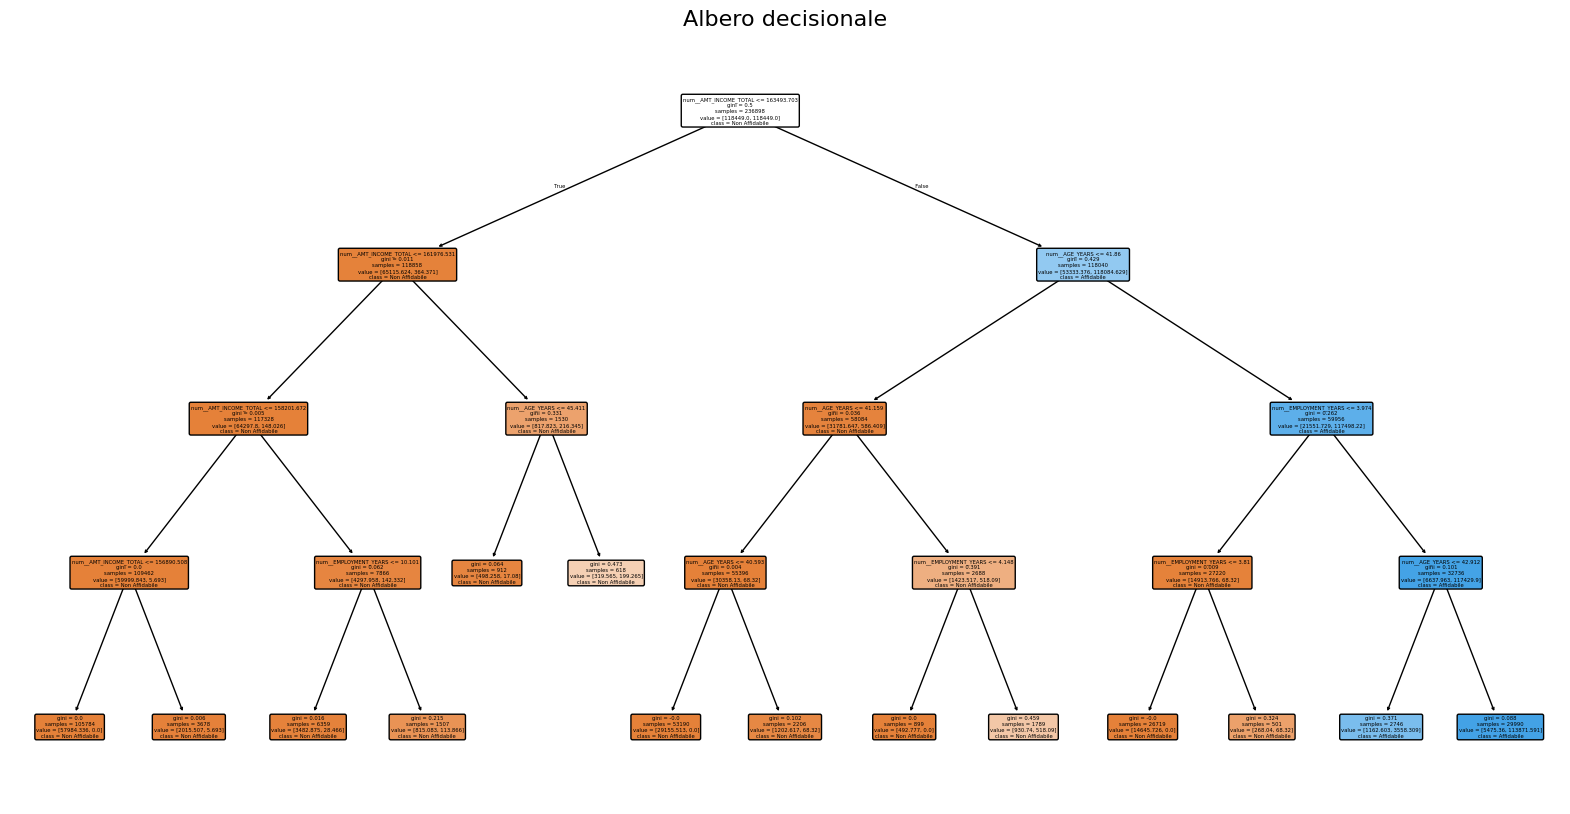

In [40]:
# Decision Tree Visualization
dtc_fitted = dtc_model.named_steps['classifier']

plt.figure(figsize=(20,10))
plot_tree(
    dtc_fitted,
    feature_names=dtc_model.named_steps['preprocess'].get_feature_names_out(),
    class_names=['Non Affidabile', 'Affidabile'],
    filled=True,
    rounded=True
)
plt.title("Albero decisionale", fontsize=16)
plt.show()

L’albero decisionale evidenzia in modo trasparente le regole principali con cui il modello distingue tra clienti affidabili e non affidabili.

Al nodo radice, la variabile più influente è **AMT_INCOME_TOTAL** :
*   se il reddito è inferiore o uguale a circa **€163.493,70**, il modello tende a classificare il cliente come non affidabile *(TARGET = 0)*;
*   se invece il reddito è superiore a questa soglia, il cliente passa ai rami destri dell’albero, dove le probabilità di affidabilità aumentano.

Nei livelli successivi compaiono altre variabili chiave:
*   **AGE_YEARS**: soglie intorno ai 42 anni discriminano tra profili più giovani, associati a maggiore rischio, e clienti più maturi, generalmente più affidabili;
*   **EMPLOYMENT_YEARS**: valori superiori a circa 4 anni rafforzano ulteriormente la classificazione positiva, indicando stabilità lavorativa.

In sintesi, il modello classifica un cliente come **"Affidabile"** grazie alla combinazione di queste variabili:
*   **Reddito > €163.493,70**
*   **Età > ~42 anni**
*   **Anni di occupazione > ~4 anni**

In [41]:
# Prediction
y_pred_dtc = dtc_model.predict(X_test)

n_reliable = sum(y_pred_dtc == 1)
n_not_reliable = sum(y_pred_dtc == 0)
n = len(y_pred_dtc)

print(f"Total customers in the test set: {n:,}")
print(f"Customers listed as RELIABLE (1): {n_reliable:,} ({n_reliable / n * 100:.2f}%)")
print(f"Customers listed as NOT RELIABLE (0): {n_not_reliable:,} ({n_not_reliable / n * 100:.2f}%)")


Total customers in the test set: 101,529
Customers listed as RELIABLE (1): 13,972 (13.76%)
Customers listed as NOT RELIABLE (0): 87,557 (86.24%)


Il Decision Tree, con 13.972 clienti classificati come affidabili, mantiene un profilo predittivo coerente e controllato, identificando correttamente la quasi totalità dei buoni clienti e contenendo il rischio di decisioni errate gravi.

## CONCLUSION

Nonostante la Random Forest abbia raggiunto le migliori prestazioni complessive (ROC-AUC ≈ 0.98) e dimostrato una maggiore capacità di generalizzazione, ho scelto di adottare come modello finale il Decision Tree per la sua superiore interpretabilità e trasparenza.

Questo modello rappresenta infatti un equilibrio ottimale tra accuratezza e interpretabilità, garantendo risultati affidabili e al tempo stesso la necessaria trasparenza nel processo decisionale indispensabile in un contesto come quello del credit scoring.